# new_VOC DLinear 简化线性预报框架

目标：用纯线性模型 (DLinear) 替代 Diffusion 范式，保留实时预览和可视化。DLinear 通过趋势-季节分解和线性层组合进行时间序列预测。

## 1) 环境与依赖初始化

In [1]:
%pip install -U --index-url https://pypi.org/simple "triton>=3.2.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import random
import sys
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn.functional as F
from IPython.display import clear_output, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# 在 notebook 中把工作目录切到 new_VOC 根目录，保证 src 可导入
WORKDIR = Path('/openbayes/home/服务外包大赛/new_VOC')
if Path.cwd() != WORKDIR:
    %cd "$WORKDIR"

try:
    import triton  # type: ignore
    triton_ver = getattr(triton, '__version__', 'unknown')
    has_tdesc = hasattr(getattr(triton, 'language', object()), 'make_tensor_descriptor')
except Exception:
    triton_ver = 'unavailable'
    has_tdesc = False

print('python:', sys.version.split()[0])
print('torch :', torch.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)
print('triton:', triton_ver, 'make_tensor_descriptor=', has_tdesc)
print('cuda available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

/usr/local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/output/服务外包大赛/new_VOC
python: 3.10.16
torch : 2.4.0+cu121
numpy : 1.26.4
pandas: 2.2.3
sklearn: 1.6.1
triton: 3.6.0 make_tensor_descriptor= True
cuda available: True
device: NVIDIA GeForce RTX 4090


In [3]:
# 定义评估函数：兼容原始版本，委托到 safety_metrics 模块
def evaluate_regression(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    回归评估函数（兼容性包装）。
    现在委托到 safety_metrics.evaluate_regression_safe 进行完整的安全导向评估。
    """
    from safety_metrics import evaluate_regression_safe
    
    # 调用安全指标模块，返回完整评估
    full_metrics = evaluate_regression_safe(y_true, y_pred)
    
    # 返回向后兼容的子集
    return {
        'avg_r2': full_metrics['avg_r2'],
        'avg_mae': full_metrics['avg_mae'],
        'avg_rmse': full_metrics['avg_rmse'],
        'trend_accuracy': full_metrics['trend_accuracy_hard'],
        'exceed_accuracy': full_metrics['exceed_accuracy'],
    }

## 2) 复制并整理可复用代码单元

本节复用旧流程中稳定的工具函数，按 数据读取/预处理/计算/可视化 组织。

In [4]:
# Triton compatibility shim
try:
    import triton  # type: ignore
    if not hasattr(triton, 'set_allocator'):
        triton.set_allocator = lambda fn: None  # type: ignore[attr-defined]
except Exception:
    pass

from src.config import DataConfig, ModelConfig, TrainConfig
from src.features import VOCSFeaturePipeline
from src.live_preview import render_live_preview
from src.model import DLinearForecaster, DLinearForecasterLarge, DLinearMambaEncoder

# 导入安全评估指标模块
from safety_metrics import evaluate_regression_safe, print_safety_metrics_summary


def count_parameters(model: torch.nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def enable_perf_flags() -> None:
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


def load_dataframe(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f'dataset not found: {csv_path}')
    return pd.read_csv(csv_path)


def build_dataloaders(df: pd.DataFrame, data_cfg: DataConfig, batch_size: int) -> Tuple[VOCSFeaturePipeline, DataLoader, DataLoader, DataLoader]:
    pipeline = VOCSFeaturePipeline(data_cfg)
    (x_train, y_train), (x_val, y_val), (x_test, y_test) = pipeline.create_temporal_datasets(df)

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    return pipeline, train_loader, val_loader, test_loader
    """
    包装函数：调用安全评估指标模块的综合评估。
    保留原始名称以保持兼容性，但使用新的安全指标实现。
    
    支持的额外指标：
    - trend_accuracy_soft: 软计算趋势准确率（考虑维持区间）
    - trend_accuracy_{step}step: 多步长变化准确率（2步、4步、8步）
    - exceed_recall: 超标召回率
    - exceed_miss_rate: 超标漏报率
    - exceed_false_positive_rate: 超标误报率
    """
    return evaluate_regression_safe(
        y_true, 
        y_pred, 
        exceed_threshold=80.0,
        tolerance=0.5,
        multi_step_list=[2, 4, 8]
    )



def preview_metrics(metrics: Dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})

## 3) 配置区重构（路径、参数、开关）

In [5]:
@dataclass
class NotebookConfig:
    dataset_csv: Path = Path('../VOCS/src/data/vocs_dataset.csv')
    output_dir: Path = Path('artifacts_dlinear_notebook')
    seed: int = 42
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    run_train: bool = True
    run_compare: bool = True
    max_train_batches: int = 0
    max_val_batches: int = 0
    max_test_batches: int = 0
    early_stop_patience: int = 2
    amp_enabled: bool = True
    enable_live_preview: bool = True
    preview_every_batches: int = 200
    preview_sample_steps: int = 8
    seq_len: int = 96
    pred_len: int = 24
    batch_size: int = 32
    epochs: int = 3
    lr: float = 1e-3
    weight_decay: float = 1e-5
    decomp_kernel: int = 25
    model_variant: str = 'timexer'  # 'base' | 'large' | 'fusion_mamba'｜gateformer | timexer
    large_hidden_dims: Tuple[int, ...] = (256, 128)
    large_branch_dropout: float = 0.1
    fusion_encoder_layers: int = 1
    enable_quick_tuning: bool = False
    tune_model_variant: str = 'gateformer'
    grid_lrs: Tuple[float, ...] = (3e-4, 1e-3, 2e-3)
    grid_decomp_kernels: Tuple[int, ...] = (15, 25, 35)
    grid_epochs: Tuple[int, ...] = (3, 5, 7)
    tuning_primary_metric: str = 'avg_r2'
    enable_fusion_test: bool = False
    fusion_use_best_tuned_params: bool = True

cfg = NotebookConfig()
set_seed(cfg.seed)
enable_perf_flags()
cfg.output_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_dir / 'models').mkdir(parents=True, exist_ok=True)
(cfg.output_dir / 'logs').mkdir(parents=True, exist_ok=True)
print(asdict(cfg))

{'dataset_csv': PosixPath('../VOCS/src/data/vocs_dataset.csv'), 'output_dir': PosixPath('artifacts_dlinear_notebook'), 'seed': 42, 'device': 'cuda', 'run_train': True, 'run_compare': True, 'max_train_batches': 0, 'max_val_batches': 0, 'max_test_batches': 0, 'early_stop_patience': 2, 'amp_enabled': True, 'enable_live_preview': True, 'preview_every_batches': 200, 'preview_sample_steps': 8, 'seq_len': 96, 'pred_len': 24, 'batch_size': 32, 'epochs': 3, 'lr': 0.001, 'weight_decay': 1e-05, 'decomp_kernel': 25, 'model_variant': 'timexer', 'large_hidden_dims': (256, 128), 'large_branch_dropout': 0.1, 'fusion_encoder_layers': 1, 'enable_quick_tuning': False, 'tune_model_variant': 'gateformer', 'grid_lrs': (0.0003, 0.001, 0.002), 'grid_decomp_kernels': (15, 25, 35), 'grid_epochs': (3, 5, 7), 'tuning_primary_metric': 'avg_r2', 'enable_fusion_test': False, 'fusion_use_best_tuned_params': True}


## 4) 搭建新框架主流程

## 5) 预留扩展点与占位函数

In [6]:
def _build_model(config: NotebookConfig, model_cfg: ModelConfig, input_dim: int, pred_len: int, seq_len: int, device: torch.device) -> Tuple[torch.nn.Module, str]:
    model_variant = str(config.model_variant).strip().lower()
    if model_variant == 'large':
        model = DLinearForecasterLarge(
            input_dim=input_dim,
            config=model_cfg,
            pred_len=pred_len,
            decomp_kernel=config.decomp_kernel,
            seq_len=seq_len,
            hidden_dims=tuple(config.large_hidden_dims),
            branch_dropout=float(config.large_branch_dropout),
        ).to(device)
        model_tag = 'dlinear_large'
    elif model_variant == 'fusion_mamba':
        model = DLinearMambaEncoder(
            input_dim=input_dim,
            config=model_cfg,
            pred_len=pred_len,
            decomp_kernel=config.decomp_kernel,
            seq_len=seq_len,
            encoder_layers=int(config.fusion_encoder_layers),
        ).to(device)
        model_tag = 'dlinear_mamba_fusion'
    elif model_variant == 'gateformer':
        model = GateformerModel(
            seq_len=seq_len,
            pred_len=pred_len,
            input_dim=input_dim,
            patch_size=16,
            stride=8,
            d_model=64
        ).to(device)
        model_tag = 'gateformer'
    elif model_variant == 'timexer':
        model = TimeXerModel(
            seq_len=seq_len,
            pred_len=pred_len,
            input_dim=input_dim,
            patch_size=16,
            d_model=128,
            n_layers=2
        ).to(device)
        model_tag = 'timexer'
    else:
        model = DLinearForecaster(
            input_dim=input_dim,
            config=model_cfg,
            pred_len=pred_len,
            decomp_kernel=config.decomp_kernel,
            seq_len=seq_len,
        ).to(device)
        model_tag = 'dlinear'
    return model, model_tag


def _metric_sort_rule(metric_name: str) -> bool:
    maximize_metrics = {'avg_r2', 'trend_accuracy', 'exceed_accuracy', 'short_r2', 'medium_r2', 'long_r2'}
    return metric_name in maximize_metrics


def main(config: NotebookConfig, run_tag: str | None = None) -> Dict[str, object]:
    print('[1/5] Load data ...')
    data_cfg = DataConfig(seq_len=config.seq_len, pred_len=config.pred_len, dataset_csv=config.dataset_csv)
    train_cfg = TrainConfig(batch_size=config.batch_size, epochs=config.epochs, learning_rate=config.lr, weight_decay=config.weight_decay, output_dir=config.output_dir)
    df = load_dataframe(data_cfg.dataset_csv)
    pipeline, train_loader, val_loader, test_loader = build_dataloaders(df, data_cfg, config.batch_size)
    device = torch.device(config.device)
    model_cfg = ModelConfig(d_model=256, n_layer=1)
    print('[2/5] Build model ...')
    model, model_tag = _build_model(config=config, model_cfg=model_cfg, input_dim=pipeline.input_dim, pred_len=data_cfg.pred_len, seq_len=data_cfg.seq_len, device=device)
    artifact_tag = model_tag if run_tag is None else f'{model_tag}_{run_tag}'
    print(f'{artifact_tag}: {count_parameters(model):,} params')
    optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg.learning_rate, weight_decay=train_cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1, threshold=1e-4, min_lr=1e-6)
    amp_enabled = bool(config.amp_enabled and device.type == 'cuda')
    scaler = torch.amp.GradScaler(device='cuda', enabled=amp_enabled)
    best_val, epochs_without_improve = float('inf'), 0
    best_ckpt = config.output_dir / 'models' / f'{artifact_tag}_best.pt'
    history, preview_dir = [], config.output_dir / 'logs' / 'train_previews'
    preview_dir.mkdir(parents=True, exist_ok=True)
    print('[3/5] Train ...')
    for epoch in range(1, train_cfg.epochs + 1):
        model.train()
        train_losses, last_xb, last_yb, last_batch_idx = [], None, None, 0
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{train_cfg.epochs} [train]', leave=False)
        for batch_idx, (xb, yb) in enumerate(train_bar, start=1):
            xb = xb.to(device, non_blocking=(device.type == 'cuda'))
            yb = yb.to(device, non_blocking=(device.type == 'cuda'))
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=amp_enabled):
                loss = model.loss(xb, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())
            last_xb, last_yb, last_batch_idx = xb, yb, batch_idx
            if config.enable_live_preview and config.preview_every_batches > 0 and batch_idx % int(config.preview_every_batches) == 0:
                model.eval()
                with torch.inference_mode():
                    pred = model.forward(xb[:1])
                    render_live_preview(epoch=epoch, batch_idx=batch_idx, y_true_scaled=yb[:1], y_pred_scaled=pred, pred_len=data_cfg.pred_len, target_scaler=pipeline.target_scaler, preview_dir=preview_dir)
                model.train()
            if config.max_train_batches > 0 and batch_idx >= config.max_train_batches:
                break
        if config.enable_live_preview and last_xb is not None and (config.preview_every_batches <= 0 or (last_batch_idx % int(config.preview_every_batches) != 0)):
            model.eval()
            with torch.inference_mode():
                pred = model.forward(last_xb[:1])
                render_live_preview(epoch=epoch, batch_idx=last_batch_idx, y_true_scaled=last_yb[:1], y_pred_scaled=pred, pred_len=data_cfg.pred_len, target_scaler=pipeline.target_scaler, preview_dir=preview_dir)
            model.train()
        model.eval()
        val_losses = []
        with torch.inference_mode():
            for batch_idx, (xb, yb) in enumerate(val_loader, start=1):
                xb = xb.to(device, non_blocking=(device.type == 'cuda'))
                yb = yb.to(device, non_blocking=(device.type == 'cuda'))
                with torch.amp.autocast(device_type='cuda', enabled=amp_enabled):
                    val_losses.append(model.loss(xb, yb).item())
                if config.max_val_batches > 0 and batch_idx >= config.max_val_batches:
                    break
        train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
        val_loss = float(np.mean(val_losses)) if val_losses else float('nan')
        scheduler.step(val_loss)
        record = {'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'lr': float(optimizer.param_groups[0]['lr'])}
        history.append(record)
        print(record)
        if val_loss < best_val:
            best_val, epochs_without_improve = val_loss, 0
            torch.save({'model_state_dict': model.state_dict(), 'model_config': model_cfg.__dict__, 'input_dim': pipeline.input_dim, 'best_val_loss': best_val, 'model_variant': str(config.model_variant).strip().lower(), 'decomp_kernel': int(config.decomp_kernel), 'epochs': int(config.epochs), 'lr': float(config.lr)}, best_ckpt)
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= config.early_stop_patience:
                print(f'Early stopping at epoch {epoch}, best={best_val:.6f}')
                break
    print('[4/5] Eval...')
    ckpt = torch.load(best_ckpt, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device)
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.inference_mode():
        for batch_idx, (xb, yb) in enumerate(tqdm(test_loader, desc='Test', leave=False), start=1):
            xb = xb.to(device, non_blocking=(device.type == 'cuda'))
            preds_scaled.append(model.forward(xb).cpu().numpy())
            trues_scaled.append(yb.numpy())
            if config.max_test_batches > 0 and batch_idx >= config.max_test_batches:
                break
    pred_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    true_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    pred_inv = pipeline.target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    true_inv = pipeline.target_scaler.inverse_transform(true_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    pred_inv = np.clip(pred_inv, 0.0, 500.0)
    metrics = evaluate_regression(true_inv, pred_inv)
    print('[5/5] Save...')
    metrics_path = config.output_dir / 'logs' / f'{artifact_tag}_metrics.json'
    with metrics_path.open('w', encoding='utf-8') as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    baseline_cmp_path = config.output_dir / 'logs' / f'{artifact_tag}_baseline_comparison.json'
    if config.run_compare and (baseline_path := Path('artifacts_notebook/logs/baseline_result.json')).exists():
        with baseline_path.open('r') as f:
            baseline = json.load(f)
        comparison = {k: {'baseline_lstm': float(baseline.get(k, float('nan'))), artifact_tag: float(metrics.get(k, float('nan'))), 'delta': float(metrics.get(k, 0.0) - baseline.get(k, 0.0))} for k in ['avg_r2', 'avg_mae', 'avg_rmse', 'trend_accuracy', 'exceed_accuracy', 'short_r2', 'medium_r2', 'long_r2']}
        with baseline_cmp_path.open('w') as f:
            json.dump(comparison, f, ensure_ascii=False, indent=2)
    return {'metrics': metrics, 'history': history, 'metrics_path': str(metrics_path), 'baseline_comparison_path': str(baseline_cmp_path), 'best_checkpoint': str(best_ckpt), 'preview_dir': str(preview_dir), 'model_tag': model_tag, 'artifact_tag': artifact_tag}


def build_quick_tuning_grid(config: NotebookConfig) -> list[dict[str, float | int]]:
    grid: list[dict[str, float | int]] = []
    epochs_options = list(config.grid_epochs) if len(config.grid_epochs) > 0 else [config.epochs]
    for i, lr in enumerate(config.grid_lrs):
        for j, kernel in enumerate(config.grid_decomp_kernels):
            epochs = int(epochs_options[(i + j) % len(epochs_options)])
            grid.append({'lr': float(lr), 'decomp_kernel': int(kernel), 'epochs': epochs})
    return grid


def run_quick_tuning(config: NotebookConfig) -> Dict[str, object]:
    grid = build_quick_tuning_grid(config)
    if len(grid) == 0:
        raise ValueError('quick tuning grid is empty.')
    metric_name = str(config.tuning_primary_metric)
    maximize = _metric_sort_rule(metric_name)
    rows = []
    print(f'Start quick tuning: {len(grid)} experiments, primary metric={metric_name}')
    for idx, setting in enumerate(grid, start=1):
        lr = float(setting['lr'])
        kernel = int(setting['decomp_kernel'])
        epochs = int(setting['epochs'])
        exp_tag = f'grid_{idx:02d}_lr{lr:.0e}_k{kernel}_e{epochs}'
        exp_cfg = replace(config, model_variant=str(config.tune_model_variant).strip().lower(), lr=lr, decomp_kernel=kernel, epochs=epochs)
        out = main(exp_cfg, run_tag=exp_tag)
        row = {
            'exp_id': idx,
            'exp_tag': exp_tag,
            'model_variant': exp_cfg.model_variant,
            'lr': lr,
            'decomp_kernel': kernel,
            'epochs': epochs,
            'best_checkpoint': out['best_checkpoint'],
            'metrics_path': out['metrics_path'],
        }
        row.update(out['metrics'])
        rows.append(row)
    summary_df = pd.DataFrame(rows)
    if metric_name not in summary_df.columns:
        raise KeyError(f'primary metric not found in summary: {metric_name}')
    summary_df = summary_df.sort_values(by=metric_name, ascending=not maximize).reset_index(drop=True)
    summary_json_path = config.output_dir / 'logs' / 'quick_tuning_summary.json'
    summary_csv_path = config.output_dir / 'logs' / 'quick_tuning_summary.csv'
    with summary_json_path.open('w', encoding='utf-8') as f:
        json.dump({'primary_metric': metric_name, 'maximize': maximize, 'total_experiments': int(len(summary_df)), 'results': summary_df.to_dict(orient='records')}, f, ensure_ascii=False, indent=2)
    summary_df.to_csv(summary_csv_path, index=False, encoding='utf-8')
    best_row = summary_df.iloc[0].to_dict()
    return {'summary_df': summary_df, 'best': best_row, 'summary_json_path': str(summary_json_path), 'summary_csv_path': str(summary_csv_path)}


def run_fusion_with_best(config: NotebookConfig, tuning_result: Dict[str, object] | None = None) -> Dict[str, object]:
    if config.fusion_use_best_tuned_params and tuning_result is not None and 'best' in tuning_result:
        best_row = tuning_result['best']
        fusion_cfg = replace(
            config,
            model_variant='fusion_mamba',
            lr=float(best_row['lr']),
            decomp_kernel=int(best_row['decomp_kernel']),
            epochs=int(best_row['epochs']),
        )
        run_tag = 'fusion_best_tuned'
    else:
        fusion_cfg = replace(config, model_variant='fusion_mamba')
        run_tag = 'fusion_default'
    return main(fusion_cfg, run_tag=run_tag)

In [7]:
import torch
import torch.nn as nn
import math

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(self.num_features))
            self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _get_statistics(self, x):
        self.mean = torch.mean(x, dim=1, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x

class GateformerModel(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, input_dim: int, 
                 patch_size: int=16, stride: int=8, d_model: int=64,
                 num_heads: int=8, d_ff: int=256, dropout: float=0.1):
        super(GateformerModel, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.input_dim = input_dim
        self.patch_size = patch_size
        self.stride = stride
        self.d_model = d_model
        
        self.revin = RevIN(num_features=input_dim)
        
        # Patching params
        self.patch_num = int((seq_len - patch_size) / stride + 2)
        
        # Branch A: Local Temporal Dependency
        self.patch_proj = nn.Linear(patch_size, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, 1, d_model))
        self.pos_emb = nn.Parameter(torch.randn(1, 1, self.patch_num + 1, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, 
                                                   dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        flat_dim = (self.patch_num + 1) * d_model
        self.branch_a_ffn = nn.Sequential(
            nn.Linear(flat_dim, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        
        # Branch B: Global Temporal Dependency
        self.branch_b_mlp = nn.Sequential(
            nn.Linear(seq_len, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )
        
        # Gated Fusion 1
        self.W_g1 = nn.Parameter(torch.randn(d_model, d_model))
        self.W_g2 = nn.Parameter(torch.randn(d_model, d_model))
        
        # Cross-Variate
        self.variate_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        
        # Output Head
        self.out_proj = nn.Linear(d_model, pred_len)
        self.variate_squeeze = nn.Linear(input_dim, 1) # since we want (B, pred_len) out of (B, N, pred_len) - simplified aggregation
        
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        # x: (B, T, N)
        B, T, N = x.shape
        x = self.revin(x, 'norm')
        
        x_t = x.permute(0, 2, 1) # (B, N, T)
        
        # --- Cross-Time Dependency ---
        # Branch A: Patching
        x_pad = nn.functional.pad(x_t, (0, self.stride)) # pad to ensure patch fits
        patches = x_pad.unfold(dimension=-1, size=self.patch_size, step=self.stride) # (B, N, P, L_p)
        P = patches.shape[2]
        
        x_p = self.patch_proj(patches) # (B, N, P, d_m)
        
        cls_tokens = self.cls_token.expand(B, N, -1, -1)
        x_p = torch.cat((cls_tokens, x_p), dim=2) # (B, N, P+1, d_m)
        
        # Ensure pos_emb matches sequence length
        actual_seq_len = x_p.shape[2]
        if self.pos_emb.shape[2] < actual_seq_len:
             # handle unexpected pad length differences safely
             x_p = x_p + nn.functional.pad(self.pos_emb, (0, 0, 0, actual_seq_len - self.pos_emb.shape[2]))[:, :, :actual_seq_len, :]
        else:
             x_p = x_p + self.pos_emb[:, :, :actual_seq_len, :]
        
        x_p_flat = x_p.view(B * N, actual_seq_len, self.d_model)
        out_time = self.transformer_encoder(x_p_flat) # (B*N, P+1, d_m)
        out_time = out_time.view(B, N, actual_seq_len * self.d_model)
        v_T = self.branch_a_ffn(out_time) # (B, N, d_m)
        
        # Branch B: Global
        v_G = self.branch_b_mlp(x_t) # (B, N, d_m)
        
        # Fusion 1
        gate = torch.sigmoid(torch.matmul(v_T, self.W_g1) + torch.matmul(v_G, self.W_g2))
        S = gate * v_T + (1 - gate) * v_G # (B, N, d_m)
        
        # --- Cross-Variate Dependency ---
        # S is treated as sequence of length N: (B, N, d_m)
        O_cv, _ = self.variate_attn(S, S, S) # (B, N, d_m)
        
        # Fusion 2 (Residual)
        out_cv = S + O_cv # (B, N, d_m)
        
        # --- Output Head ---
        out = self.out_proj(out_cv) # (B, N, pred_len)
        out = out.permute(0, 2, 1) # (B, pred_len, N)
        
        # RevIN denorm
        out = self.revin(out, 'denorm') # (B, pred_len, N)
        
        # Aggregate to single variate prediction
        out = self.variate_squeeze(out) # (B, pred_len, 1) to match yb
        
        return out

    def loss(self, xb, yb):
        pred = self.forward(xb)
        return self.loss_fn(pred, yb)

## 6) 执行主流程并输出关键结果

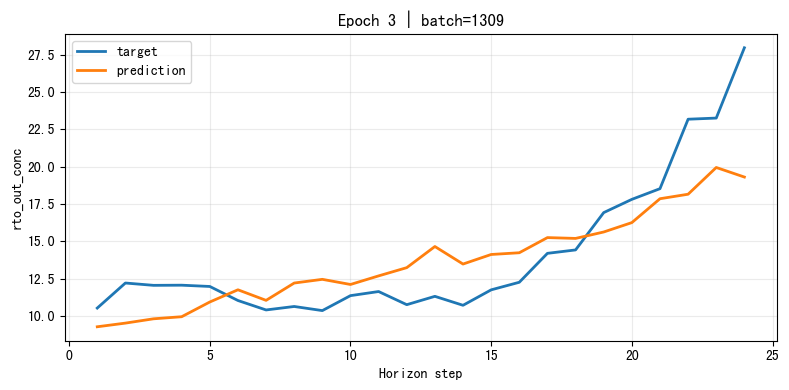

{'epoch': 3, 'train_loss': 0.010143836089171543, 'val_loss': 0.011273618767641193, 'lr': 0.001}
[4/5] Eval...


NameError: name 'evaluate_regression' is not defined

In [11]:
result = main(cfg, run_tag='single')

tuning_result = None
if cfg.enable_quick_tuning:
    tuning_result = run_quick_tuning(cfg)
    print('quick tuning summary json:', tuning_result['summary_json_path'])
    print('quick tuning summary csv :', tuning_result['summary_csv_path'])
    display(tuning_result['summary_df'].head(10))

fusion_result = None
if cfg.enable_fusion_test:
    fusion_result = run_fusion_with_best(cfg, tuning_result=tuning_result)
    print('fusion best checkpoint:', fusion_result['best_checkpoint'])
    print('fusion metrics path   :', fusion_result['metrics_path'])

metrics_df = preview_metrics(result['metrics'])
metrics_df

In [ ]:
# 可选快速烟雾测试：小批次验证 quick tuning 与 fusion_mamba 流程可执行。
smoke_cfg = replace(
    cfg,
    max_train_batches=20,
    max_val_batches=10,
    max_test_batches=10,
    enable_live_preview=False,
)

# 1) quick tuning smoke（1组）
quick_tune_smoke_cfg = replace(
    smoke_cfg,
    tune_model_variant='large',
    grid_lrs=(1e-3,),
    grid_decomp_kernels=(25,),
    grid_epochs=(3,),
)
quick_tune_smoke = run_quick_tuning(quick_tune_smoke_cfg)
print('quick tuning smoke summary:', quick_tune_smoke['summary_json_path'])
display(quick_tune_smoke['summary_df'])

# 2) fusion_mamba smoke（1次）
fusion_smoke_cfg = replace(
    smoke_cfg,
    model_variant='fusion_mamba',
    epochs=1,
    lr=3e-4,
    decomp_kernel=25,
    fusion_encoder_layers=1,
)
fusion_smoke = main(fusion_smoke_cfg, run_tag='fusion_smoke')
print('fusion smoke checkpoint:', fusion_smoke['best_checkpoint'])
print('fusion smoke metrics   :', fusion_smoke['metrics'])

Start quick tuning: 1 experiments, primary metric=avg_r2
[1/5] Load data ...
[2/5] Build model ...
dlinear_large_grid_01_lr1e-03_k25_e3: 121,648 params
[3/5] Train ...


{'epoch': 1, 'train_loss': 0.038309432845562694, 'val_loss': 0.024436799553222956, 'lr': 0.001}


{'epoch': 2, 'train_loss': 0.017691570706665515, 'val_loss': 0.01528388315346092, 'lr': 0.001}


{'epoch': 3, 'train_loss': 0.014276088750921189, 'val_loss': 0.01327511565759778, 'lr': 0.001}
[4/5] Eval...


[5/5] Save...
quick tuning smoke summary: artifacts_dlinear_notebook/logs/quick_tuning_summary.json


,exp_id,exp_tag,model_variant,lr,decomp_kernel,epochs,best_checkpoint,metrics_path,avg_r2,avg_mae,avg_rmse,trend_accuracy,exceed_accuracy,short_r2,medium_r2,long_r2
0,1,grid_01_lr1e-03_k25_e3,large,0.001,25,3,artifacts_dlinear_notebook/models/dlinear_larg...,artifacts_dlinear_notebook/logs/dlinear_large_...,0.333798,8.714536,9.983364,0.508832,1.0,0.681893,0.285903,0.031688


[1/5] Load data ...
[2/5] Build model ...
dlinear_mamba_fusion_fusion_smoke: 758,081 params
[3/5] Train ...


{'epoch': 1, 'train_loss': 6.729126499593258, 'val_loss': 0.0948620405048132, 'lr': 0.0003}
[4/5] Eval...


[5/5] Save...
fusion smoke checkpoint: artifacts_dlinear_notebook/models/dlinear_mamba_fusion_fusion_smoke_best.pt
fusion smoke metrics   : {'avg_r2': -3.8748416205247245, 'avg_mae': 23.789077560106914, 'avg_rmse': 27.137777847472023, 'trend_accuracy': 0.4626358695652174, 'exceed_accuracy': 1.0, 'short_r2': -4.358936309814453, 'medium_r2': -3.6589479446411133, 'long_r2': -3.5906481742858887}


In [ ]:
# 正式实验开关：启动9组快速调参与融合测试
cfg.enable_quick_tuning = True
cfg.enable_fusion_test = True
cfg.fusion_use_best_tuned_params = True

# 正式训练保持全数据；为缩短总时长，关闭批内预览图
cfg.max_train_batches = 0
cfg.max_val_batches = 0
cfg.max_test_batches = 0
cfg.enable_live_preview = False

print('ready to run full experiments:', {
    'enable_quick_tuning': cfg.enable_quick_tuning,
    'enable_fusion_test': cfg.enable_fusion_test,
    'grid_lrs': cfg.grid_lrs,
    'grid_decomp_kernels': cfg.grid_decomp_kernels,
    'grid_epochs': cfg.grid_epochs,
    'tune_model_variant': cfg.tune_model_variant,
    'enable_live_preview': cfg.enable_live_preview,
})

ready to run full experiments: {'enable_quick_tuning': True, 'enable_fusion_test': True, 'grid_lrs': (0.0003, 0.001, 0.002), 'grid_decomp_kernels': (15, 25, 35), 'grid_epochs': (3, 5, 7), 'tune_model_variant': 'large', 'enable_live_preview': False}


In [8]:
# 深层 DLinear large 实验：在当前 large 最优超参基础上增加分支层数。
# 当前最优（来自 quick tuning）：lr=3e-4, decomp_kernel=35, epochs=7
# 本实验仅增加 large_hidden_dims，从 (256,128) -> (512,256,128)。

deep_large_cfg = replace(
    cfg,
    model_variant='large',
    large_hidden_dims=(96,48,24),
    lr=3e-4,
    decomp_kernel=35,
    epochs=7,
    enable_quick_tuning=False,
    enable_fusion_test=False,
    enable_live_preview=False,
)

deep_large_result = main(deep_large_cfg, run_tag='deep_large_96_48_24')
print('deep large checkpoint:', deep_large_result['best_checkpoint'])
print('deep large metrics   :', deep_large_result['metrics'])
preview_metrics(deep_large_result['metrics'])

[1/5] Load data ...
[2/5] Build model ...
dlinear_large_deep_large_96_48_24: 31,488 params
[3/5] Train ...


{'epoch': 1, 'train_loss': 0.017563625538723104, 'val_loss': 0.01054596354409363, 'lr': 0.0003}


{'epoch': 2, 'train_loss': 0.010379002102621531, 'val_loss': 0.01019825588156108, 'lr': 0.0003}


{'epoch': 3, 'train_loss': 0.009890460464363452, 'val_loss': 0.010070427220225255, 'lr': 0.0003}


{'epoch': 4, 'train_loss': 0.00966158733280579, 'val_loss': 0.010066735351067103, 'lr': 0.0003}


{'epoch': 5, 'train_loss': 0.009539461425363995, 'val_loss': 0.009986885569557163, 'lr': 0.0003}


{'epoch': 6, 'train_loss': 0.009477459990460001, 'val_loss': 0.009991557836148132, 'lr': 0.0003}


{'epoch': 7, 'train_loss': 0.009432920997192538, 'val_loss': 0.010058315819232092, 'lr': 0.00015}
Early stopping at epoch 7, best=0.009987
[4/5] Eval...


[5/5] Save...
deep large checkpoint: artifacts_dlinear_notebook/models/dlinear_large_deep_large_96_48_24_best.pt
deep large metrics   : {'avg_r2': 0.642799494167169, 'avg_mae': 7.248011509577434, 'avg_rmse': 9.440490141960554, 'trend_accuracy': 0.5343026381428869, 'exceed_accuracy': 0.9942399093980914}


,metric,value
0,avg_r2,0.642799
1,avg_mae,7.248012
2,avg_rmse,9.440490
3,trend_accuracy,0.534303
4,exceed_accuracy,0.994240


In [9]:
# 定义评估函数：兼容原始版本，委托到 safety_metrics 模块
def evaluate_regression(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    回归评估函数（兼容性包装）。
    现在委托到 safety_metrics.evaluate_regression_safe 进行完整的安全导向评估。
    """
    from safety_metrics import evaluate_regression_safe
    
    # 调用安全指标模块，返回完整评估
    full_metrics = evaluate_regression_safe(y_true, y_pred)
    
    # 返回向后兼容的子集
    return {
        'avg_r2': full_metrics['avg_r2'],
        'avg_mae': full_metrics['avg_mae'],
        'avg_rmse': full_metrics['avg_rmse'],
        'trend_accuracy': full_metrics['trend_accuracy_hard'],
        'exceed_accuracy': full_metrics['exceed_accuracy'],
    }

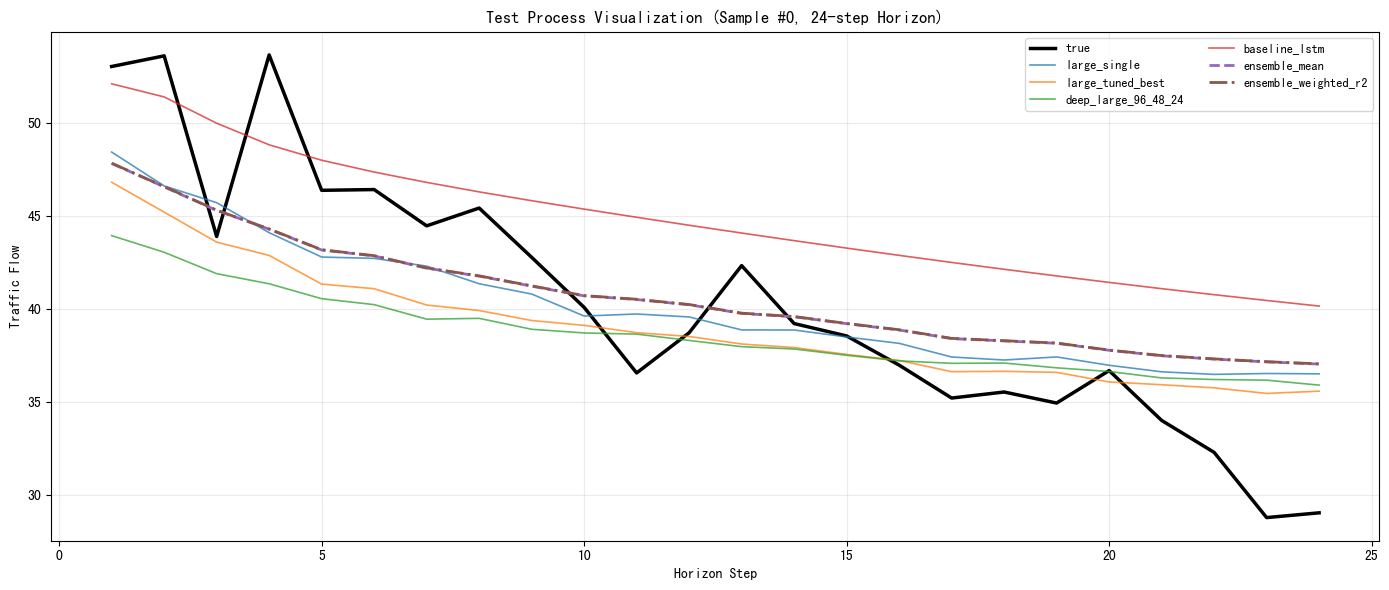

ensemble members: ['large_single', 'large_tuned_best', 'deep_large_96_48_24', 'baseline_lstm']
weights (r2): {'large_single': 0.24936145100153778, 'large_tuned_best': 0.24899616682248543, 'deep_large_96_48_24': 0.2492986652699316, 'baseline_lstm': 0.2523437169060451}
ensemble summary saved: artifacts_dlinear_notebook/logs/ensemble_evaluation_summary.csv
test visualization saved: artifacts_dlinear_notebook/logs/ensemble_test_process_visualization.png


,name,type,model_tag,infer_total_sec,infer_ms_per_window,avg_r2,avg_mae,avg_rmse,trend_accuracy,exceed_accuracy
0,ensemble_weighted_r2,ensemble,soft_voting_weighted,3.269606,0.364220,0.652340,7.142409,9.260356,0.538221,0.994296
1,ensemble_mean,ensemble,soft_voting_mean,3.260342,0.363188,0.652289,7.142766,9.261167,0.538201,0.994296
2,baseline_lstm,single,baseline_lstm_l3_baseline,2.229325,0.248337,0.650651,7.252012,9.332653,0.539374,0.994175
3,large_single,single,large_256x128,0.333416,0.037141,0.642961,7.328420,9.420076,0.535039,0.993915
4,deep_large_96_48_24,single,large_96x48x24,0.357555,0.039830,0.642799,7.248012,9.440490,0.534303,0.994240
5,large_tuned_best,single,large_256x128,0.339707,0.037842,0.642020,7.170730,9.434452,0.533164,0.994272


In [10]:
# 集成学习评估：回滚为稳定的 DLinear + baseline LSTM (+ 1层LSTM) 方案，并保留测试可视化与推理耗时统计。
import re
import sys
import time
import pickle

from compare_with_vocs_baseline import temporal_split_with_context, create_lstm_sequences

vocs_src_root = Path('/openbayes/home/服务外包大赛/VOCS/src')
if str(vocs_src_root) not in sys.path:
    sys.path.append(str(vocs_src_root))

from vocs_model import Config as LSTMConfig
from vocs_model import ImprovedSeq2SeqModel


def _infer_hidden_dims_from_state_dict(state_dict: dict) -> Tuple[int, ...]:
    if 'trend_linear.weight' in state_dict:
        return tuple()
    linear_layers = []
    for k, v in state_dict.items():
        m = re.match(r'^trend_linear\.(\d+)\.weight$', k)
        if m:
            linear_layers.append((int(m.group(1)), tuple(v.shape)))
    linear_layers = sorted(linear_layers, key=lambda x: x[0])
    if len(linear_layers) <= 1:
        return tuple()
    return tuple(int(shape[0]) for _, shape in linear_layers[:-1])


def _infer_encoder_layers_from_state_dict(state_dict: dict) -> int:
    idx_set = set()
    for k in state_dict.keys():
        m = re.match(r'^encoder\.(\d+)\.', k)
        if m:
            idx_set.add(int(m.group(1)))
    return max(1, len(idx_set))


def _infer_lstm_layers_from_state_dict(state_dict: dict) -> int:
    layer_ids = []
    for k in state_dict.keys():
        m = re.match(r'^encoder\.weight_ih_l(\d+)$', k)
        if m:
            layer_ids.append(int(m.group(1)))
    return int(max(layer_ids) + 1) if len(layer_ids) > 0 else 1


def _sync_cuda_if_needed(device: torch.device) -> None:
    if device.type == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()


def _build_dlinear_family_model(
    ckpt: dict,
    cfg_ref: NotebookConfig,
    input_dim: int,
    pred_len: int,
    seq_len: int,
    device: torch.device,
) -> Tuple[torch.nn.Module, str]:
    model_cfg = ModelConfig(**ckpt['model_config'])
    state_dict = ckpt['model_state_dict']
    model_variant = str(ckpt.get('model_variant', 'large')).lower()
    decomp_kernel = int(ckpt.get('decomp_kernel', cfg_ref.decomp_kernel))

    if 'fusion' in model_variant or 'mamba' in model_variant:
        encoder_layers = _infer_encoder_layers_from_state_dict(state_dict)
        model = DLinearMambaEncoder(
            input_dim=input_dim,
            config=model_cfg,
            pred_len=pred_len,
            decomp_kernel=decomp_kernel,
            seq_len=seq_len,
            encoder_layers=encoder_layers,
        ).to(device)
        tag = f'mamba3_linear_fusion_l{encoder_layers}'
    else:
        hidden_dims = _infer_hidden_dims_from_state_dict(state_dict)
        if len(hidden_dims) > 0:
            model = DLinearForecasterLarge(
                input_dim=input_dim,
                config=model_cfg,
                pred_len=pred_len,
                decomp_kernel=decomp_kernel,
                seq_len=seq_len,
                hidden_dims=hidden_dims,
                branch_dropout=float(cfg_ref.large_branch_dropout),
            ).to(device)
            tag = f'large_{"x".join(map(str, hidden_dims))}'
        else:
            model = DLinearForecaster(
                input_dim=input_dim,
                config=model_cfg,
                pred_len=pred_len,
                decomp_kernel=decomp_kernel,
                seq_len=seq_len,
            ).to(device)
            tag = 'base'

    model.load_state_dict(state_dict)
    model.eval()
    return model, tag


def evaluate_dlinear_family_checkpoint(ckpt_path: Path, cfg_ref: NotebookConfig) -> Dict[str, object]:
    data_cfg = DataConfig(seq_len=cfg_ref.seq_len, pred_len=cfg_ref.pred_len, dataset_csv=cfg_ref.dataset_csv)
    df_eval = load_dataframe(data_cfg.dataset_csv)
    pipeline_eval, _, _, test_loader_eval = build_dataloaders(df_eval, data_cfg, cfg_ref.batch_size)

    device_eval = torch.device(cfg_ref.device)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model, model_tag = _build_dlinear_family_model(
        ckpt=ckpt,
        cfg_ref=cfg_ref,
        input_dim=int(ckpt.get('input_dim', pipeline_eval.input_dim)),
        pred_len=data_cfg.pred_len,
        seq_len=data_cfg.seq_len,
        device=device_eval,
    )

    preds_scaled, trues_scaled = [], []
    _sync_cuda_if_needed(device_eval)
    t0 = time.perf_counter()
    with torch.inference_mode():
        for xb, yb in tqdm(test_loader_eval, desc=f'test:{ckpt_path.stem}', leave=False):
            xb = xb.to(device_eval, non_blocking=(device_eval.type == 'cuda'))
            pred = model.forward(xb).cpu().numpy()
            preds_scaled.append(pred)
            trues_scaled.append(yb.numpy())
    _sync_cuda_if_needed(device_eval)
    infer_total_sec = float(time.perf_counter() - t0)

    pred_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    true_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    pred_inv = pipeline_eval.target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    true_inv = pipeline_eval.target_scaler.inverse_transform(true_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    pred_inv = np.clip(pred_inv, 0.0, 500.0)
    metrics = evaluate_regression(true_inv, pred_inv)

    n_windows = int(pred_inv.shape[0])
    timing = {
        'infer_total_sec': infer_total_sec,
        'infer_ms_per_window': float(infer_total_sec * 1000.0 / max(1, n_windows)),
    }

    return {
        'checkpoint': str(ckpt_path),
        'model_tag': model_tag,
        'metrics': metrics,
        'timing': timing,
        'pred_inv': pred_inv,
        'true_inv': true_inv,
    }


def evaluate_lstm_checkpoint(
    ckpt_path: Path,
    scaler_path: Path,
    cfg_ref: NotebookConfig,
    force_layers: int | None = None,
    strict_load: bool = True,
    name_suffix: str = '',
) -> Dict[str, object]:
    data_cfg = DataConfig(seq_len=cfg_ref.seq_len, pred_len=cfg_ref.pred_len, dataset_csv=cfg_ref.dataset_csv)
    df_eval = load_dataframe(data_cfg.dataset_csv)
    _, _, test_df = temporal_split_with_context(df_eval, data_cfg)

    with scaler_path.open('rb') as f:
        scaler_payload = pickle.load(f)
    feature_scaler = scaler_payload['feature_scaler']
    target_scaler = scaler_payload['target_scaler']
    feature_columns = scaler_payload['feature_columns']

    x_test, y_test = create_lstm_sequences(
        test_df,
        feature_scaler,
        target_scaler,
        feature_columns,
        seq_len=data_cfg.seq_len,
        pred_len=data_cfg.pred_len,
    )

    device_eval = torch.device(cfg_ref.device)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state_dict = ckpt['model_state_dict']
    inferred_layers = _infer_lstm_layers_from_state_dict(state_dict)
    num_layers = int(force_layers) if force_layers is not None else int(inferred_layers)

    lstm_cfg = LSTMConfig()
    lstm_cfg.NUM_LAYERS = int(num_layers)
    model = ImprovedSeq2SeqModel(lstm_cfg, x_test.shape[-1]).to(device_eval)
    model.load_state_dict(state_dict, strict=bool(strict_load))
    model.eval()

    loader = DataLoader(
        TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)),
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )

    preds_scaled, trues_scaled = [], []
    _sync_cuda_if_needed(device_eval)
    t0 = time.perf_counter()
    with torch.inference_mode():
        for xb, yb in tqdm(loader, desc=f'test:{ckpt_path.stem}', leave=False):
            xb = xb.to(device_eval)
            pred = model(xb, target=None, teacher_forcing_ratio=0.0).cpu().numpy()
            preds_scaled.append(pred)
            trues_scaled.append(yb.numpy())
    _sync_cuda_if_needed(device_eval)
    infer_total_sec = float(time.perf_counter() - t0)

    pred_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    true_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, data_cfg.pred_len)
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    true_inv = target_scaler.inverse_transform(true_scaled.reshape(-1, 1)).reshape(-1, data_cfg.pred_len)
    pred_inv = np.clip(pred_inv, 0.0, 500.0)
    metrics = evaluate_regression(true_inv, pred_inv)

    n_windows = int(pred_inv.shape[0])
    timing = {
        'infer_total_sec': infer_total_sec,
        'infer_ms_per_window': float(infer_total_sec * 1000.0 / max(1, n_windows)),
    }

    suffix = f'_{name_suffix}' if len(name_suffix) > 0 else ''
    return {
        'checkpoint': str(ckpt_path),
        'model_tag': f'baseline_lstm_l{num_layers}{suffix}',
        'metrics': metrics,
        'timing': timing,
        'pred_inv': pred_inv,
        'true_inv': true_inv,
    }


def _existing(items):
    return [it for it in items if it['path'] is not None and Path(it['path']).exists()]


def _visualize_test_process(
    true_inv: np.ndarray,
    member_names: list[str],
    member_results: dict[str, dict[str, object]],
    mean_pred: np.ndarray,
    weighted_pred: np.ndarray,
    out_path: Path,
) -> None:
    if true_inv.shape[0] == 0:
        return

    steps = np.arange(1, true_inv.shape[1] + 1)
    sample_idx = 0

    plt.figure(figsize=(14, 6))
    plt.plot(steps, true_inv[sample_idx], label='true', color='black', linewidth=2.5)
    for name in member_names:
        plt.plot(steps, member_results[name]['pred_inv'][sample_idx], label=name, alpha=0.75, linewidth=1.2)
    plt.plot(steps, mean_pred[sample_idx], label='ensemble_mean', linestyle='--', linewidth=2.0)
    plt.plot(steps, weighted_pred[sample_idx], label='ensemble_weighted_r2', linestyle='-.', linewidth=2.0)
    plt.title('Test Process Visualization (Sample #0, 24-step Horizon)')
    plt.xlabel('Horizon Step')
    plt.ylabel('Traffic Flow')
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


model_dir = cfg.output_dir / 'models'
vocs_models_dir = Path('/openbayes/home/服务外包大赛/VOCS/src/outputs/20260203_105917/models')
baseline_ckpt = vocs_models_dir / 'vocs_seq2seq_v2_best.pth'
baseline_scaler = vocs_models_dir / 'vocs_scalers_v2.pkl'

# 兼容 .pt/.pth + 多种命名
one_layer_candidates = []
name_tokens = ['1layer', '1_layer', 'one_layer', 'l1', 'half_layers']
for ext in ['pt', 'pth']:
    for tok in name_tokens:
        one_layer_candidates.extend(model_dir.glob(f'*{tok}*.{ext}'))
if 'baseline_1layer_ckpt' in globals():
    try:
        one_layer_candidates.append(Path(baseline_1layer_ckpt))
    except Exception:
        pass
one_layer_candidates = sorted(set([p for p in one_layer_candidates if p.exists()]))
one_layer_ckpt = one_layer_candidates[0] if len(one_layer_candidates) > 0 else None

# 回滚后的统一成员清单：仅 DLinear + LSTM（下一步融入mamba3）
member_specs = [
    {'name': 'large_single', 'family': 'dlinear', 'path': model_dir / 'dlinear_large_single_best.pt'},
    {'name': 'large_tuned_best', 'family': 'dlinear', 'path': model_dir / 'dlinear_large_grid_03_lr3e-04_k35_e7_best.pt'},
    {'name': 'deep_large_96_48_24', 'family': 'dlinear', 'path': model_dir / 'dlinear_large_deep_large_96_48_24_best.pt'},
    {'name': 'baseline_lstm', 'family': 'lstm', 'path': baseline_ckpt, 'scaler_path': baseline_scaler, 'force_layers': None, 'strict_load': True, 'name_suffix': 'baseline'},
    # {
    #     'name': 'baseline_lstm_1layer',
    #     'family': 'lstm',
    #     'path': one_layer_ckpt if one_layer_ckpt is not None else baseline_ckpt,
    #     'scaler_path': baseline_scaler,
    #     'force_layers': 1,
    #     'strict_load': bool(one_layer_ckpt is not None),
    #     'name_suffix': 'ckpt' if one_layer_ckpt is not None else 'from_baseline',
    # },
]

member_specs = _existing(member_specs)
if len(member_specs) < 2:
    raise RuntimeError('可用集成成员不足，至少需要2个checkpoint。')

member_results = {}
for spec in member_specs:
    if spec['family'] == 'dlinear':
        member_results[spec['name']] = evaluate_dlinear_family_checkpoint(spec['path'], cfg)
    else:
        member_results[spec['name']] = evaluate_lstm_checkpoint(
            ckpt_path=spec['path'],
            scaler_path=spec['scaler_path'],
            cfg_ref=cfg,
            force_layers=spec['force_layers'],
            strict_load=spec['strict_load'],
            name_suffix=spec['name_suffix'],
        )

member_names = list(member_results.keys())
stack_preds = np.stack([member_results[n]['pred_inv'] for n in member_names], axis=0)
true_inv_ref = member_results[member_names[0]]['true_inv']

t_mean0 = time.perf_counter()
mean_pred = np.mean(stack_preds, axis=0)
mean_infer_sec = float(time.perf_counter() - t_mean0)
mean_metrics = evaluate_regression(true_inv_ref, mean_pred)

r2_weights = np.array([max(0.0, member_results[n]['metrics']['avg_r2']) for n in member_names], dtype=np.float64)
if np.allclose(r2_weights.sum(), 0.0):
    r2_weights = np.ones_like(r2_weights)
r2_weights = r2_weights / r2_weights.sum()

t_weight0 = time.perf_counter()
weighted_pred = np.tensordot(r2_weights, stack_preds, axes=(0, 0))
weighted_infer_sec = float(time.perf_counter() - t_weight0)
weighted_metrics = evaluate_regression(true_inv_ref, weighted_pred)

member_total_sec = float(np.sum([member_results[n]['timing']['infer_total_sec'] for n in member_names]))
n_windows = int(true_inv_ref.shape[0])

rows = [
    {
        'name': n,
        'type': 'single',
        'model_tag': member_results[n]['model_tag'],
        'infer_total_sec': float(member_results[n]['timing']['infer_total_sec']),
        'infer_ms_per_window': float(member_results[n]['timing']['infer_ms_per_window']),
        **member_results[n]['metrics'],
    }
    for n in member_names
]
rows.append({
    'name': 'ensemble_mean',
    'type': 'ensemble',
    'model_tag': 'soft_voting_mean',
    'infer_total_sec': float(member_total_sec + mean_infer_sec),
    'infer_ms_per_window': float((member_total_sec + mean_infer_sec) * 1000.0 / max(1, n_windows)),
    **mean_metrics,
})
rows.append({
    'name': 'ensemble_weighted_r2',
    'type': 'ensemble',
    'model_tag': 'soft_voting_weighted',
    'infer_total_sec': float(member_total_sec + weighted_infer_sec),
    'infer_ms_per_window': float((member_total_sec + weighted_infer_sec) * 1000.0 / max(1, n_windows)),
    **weighted_metrics,
})

ensemble_df = pd.DataFrame(rows)
ensemble_df = ensemble_df.sort_values(by=['avg_r2', 'avg_mae'], ascending=[False, True]).reset_index(drop=True)

ensemble_summary_path = cfg.output_dir / 'logs' / 'ensemble_evaluation_summary.csv'
ensemble_df.to_csv(ensemble_summary_path, index=False, encoding='utf-8')

viz_path = cfg.output_dir / 'logs' / 'ensemble_test_process_visualization.png'
_visualize_test_process(
    true_inv=true_inv_ref,
    member_names=member_names,
    member_results=member_results,
    mean_pred=mean_pred,
    weighted_pred=weighted_pred,
    out_path=viz_path,
)

print('ensemble members:', member_names)
print('weights (r2):', {n: float(w) for n, w in zip(member_names, r2_weights)})
print('ensemble summary saved:', ensemble_summary_path)
print('test visualization saved:', viz_path)
ensemble_df

In [15]:
# 基线层数变体实验：构建当前基线的 1/2 层数、3/4 层数 LSTM，单独训练并测评，并保存到 DLinear models 目录。
import math
import copy
import pickle

from compare_with_vocs_baseline import temporal_split_with_context, create_lstm_sequences
from vocs_model import Config as LSTMConfig
from vocs_model import ImprovedSeq2SeqModel


def infer_baseline_layers(ckpt_path: Path) -> int:
    ckpt_obj = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = ckpt_obj['model_state_dict']
    layer_ids = sorted({int(k.split('encoder.weight_ih_l')[-1]) for k in sd.keys() if k.startswith('encoder.weight_ih_l')})
    return len(layer_ids) if len(layer_ids) > 0 else 1


def train_eval_lstm_variant(
    variant_name: str,
    num_layers: int,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    target_scaler,
    device: torch.device,
    epochs: int = 12,
    batch_size: int = 64,
    lr: float = 8e-4,
    weight_decay: float = 1e-5,
    patience: int = 3,
    grad_clip: float = 1.0,
    tf_ratio: float = 0.3,
    save_path: Path | None = None,
) -> Dict[str, object]:
    cfg_lstm = LSTMConfig()
    cfg_lstm.NUM_LAYERS = int(num_layers)
    cfg_lstm.BATCH_SIZE = int(batch_size)
    cfg_lstm.LEARNING_RATE = float(lr)
    cfg_lstm.WEIGHT_DECAY = float(weight_decay)
    cfg_lstm.EPOCHS = int(epochs)
    cfg_lstm.EARLY_STOP_PATIENCE = int(patience)
    cfg_lstm.GRAD_CLIP = float(grad_clip)

    model = ImprovedSeq2SeqModel(cfg_lstm, input_dim=x_train.shape[-1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg_lstm.LEARNING_RATE, weight_decay=cfg_lstm.WEIGHT_DECAY)
    criterion = torch.nn.MSELoss()

    train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)), batch_size=cfg_lstm.BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val)), batch_size=cfg_lstm.BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)), batch_size=cfg_lstm.BATCH_SIZE, shuffle=False, num_workers=0)

    best_val = float('inf')
    bad_epochs = 0
    best_state = None

    for epoch in range(1, cfg_lstm.EPOCHS + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb, target=yb, teacher_forcing_ratio=tf_ratio)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg_lstm.GRAD_CLIP)
            optimizer.step()
            train_losses.append(float(loss.item()))

        model.eval()
        val_losses = []
        with torch.inference_mode():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb, target=None, teacher_forcing_ratio=0.0)
                val_losses.append(float(criterion(pred, yb).item()))

        tr_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else float('nan')
        va_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else float('nan')
        print(f'[{variant_name}] epoch={epoch:02d} train={tr_loss:.6f} val={va_loss:.6f}')

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg_lstm.EARLY_STOP_PATIENCE:
                print(f'[{variant_name}] early stop at epoch {epoch}, best_val={best_val:.6f}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(
            {
                'model_state_dict': copy.deepcopy(model.state_dict()),
                'num_layers': int(num_layers),
                'input_dim': int(x_train.shape[-1]),
                'best_val_loss': float(best_val),
                'variant_name': str(variant_name),
                'lstm_config': {
                    'NUM_LAYERS': int(cfg_lstm.NUM_LAYERS),
                    'BATCH_SIZE': int(cfg_lstm.BATCH_SIZE),
                    'LEARNING_RATE': float(cfg_lstm.LEARNING_RATE),
                    'WEIGHT_DECAY': float(cfg_lstm.WEIGHT_DECAY),
                    'EPOCHS': int(cfg_lstm.EPOCHS),
                    'EARLY_STOP_PATIENCE': int(cfg_lstm.EARLY_STOP_PATIENCE),
                    'GRAD_CLIP': float(cfg_lstm.GRAD_CLIP),
                },
            },
            save_path,
        )

    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.inference_mode():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb, target=None, teacher_forcing_ratio=0.0).cpu().numpy()
            preds_scaled.append(pred)
            trues_scaled.append(yb.numpy())

    pred_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, y_test.shape[1])
    true_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, y_test.shape[1])
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1, y_test.shape[1])
    true_inv = target_scaler.inverse_transform(true_scaled.reshape(-1, 1)).reshape(-1, y_test.shape[1])
    pred_inv = np.clip(pred_inv, 0.0, 500.0)
    metrics = evaluate_regression(true_inv, pred_inv)

    return {
        'variant': variant_name,
        'num_layers': int(num_layers),
        'best_val_loss': float(best_val),
        'checkpoint_path': str(save_path) if save_path is not None else None,
        'metrics': metrics,
    }


baseline_ckpt_path = Path('/openbayes/home/服务外包大赛/VOCS/src/outputs/20260203_105917/models/vocs_seq2seq_v2_best.pth')
baseline_scaler_path = Path('/openbayes/home/服务外包大赛/VOCS/src/outputs/20260203_105917/models/vocs_scalers_v2.pkl')
if not baseline_ckpt_path.exists() or not baseline_scaler_path.exists():
    raise FileNotFoundError('baseline checkpoint/scaler not found.')

data_cfg = DataConfig(seq_len=cfg.seq_len, pred_len=cfg.pred_len, dataset_csv=cfg.dataset_csv)
df_all = load_dataframe(cfg.dataset_csv)
train_df, val_df, test_df = temporal_split_with_context(df_all, data_cfg)

with baseline_scaler_path.open('rb') as f:
    scaler_payload = pickle.load(f)
feature_scaler = scaler_payload['feature_scaler']
target_scaler = scaler_payload['target_scaler']
feature_columns = scaler_payload['feature_columns']

x_train, y_train = create_lstm_sequences(train_df, feature_scaler, target_scaler, feature_columns, seq_len=data_cfg.seq_len, pred_len=data_cfg.pred_len)
x_val, y_val = create_lstm_sequences(val_df, feature_scaler, target_scaler, feature_columns, seq_len=data_cfg.seq_len, pred_len=data_cfg.pred_len)
x_test, y_test = create_lstm_sequences(test_df, feature_scaler, target_scaler, feature_columns, seq_len=data_cfg.seq_len, pred_len=data_cfg.pred_len)

base_layers = infer_baseline_layers(baseline_ckpt_path)
half_layers = max(1, int(math.floor(base_layers * 0.5)))
three_quarter_layers = max(1, int(math.floor(base_layers * 0.75)))
plan = [('baseline_lstm_half_layers', half_layers), ('baseline_lstm_three_quarter_layers', three_quarter_layers)]
print('baseline original layers:', base_layers)
print('variant plan:', plan)

device = torch.device(cfg.device)
variant_model_dir = cfg.output_dir / 'models'
variant_model_dir.mkdir(parents=True, exist_ok=True)
results = []
for name, n_layers in plan:
    variant_ckpt = variant_model_dir / f'{name}_best.pth'
    out = train_eval_lstm_variant(
        variant_name=name,
        num_layers=n_layers,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        x_test=x_test,
        y_test=y_test,
        target_scaler=target_scaler,
        device=device,
        epochs=12,
        batch_size=64,
        lr=8e-4,
        weight_decay=1e-5,
        patience=3,
        grad_clip=1.0,
        tf_ratio=0.3,
        save_path=variant_ckpt,
    )
    print(f"saved model checkpoint: {variant_ckpt}")
    results.append(out)

rows = []
for out in results:
    rows.append(
        {
            'name': out['variant'],
            'num_layers': out['num_layers'],
            'best_val_loss': out['best_val_loss'],
            'checkpoint_path': out['checkpoint_path'],
            **out['metrics'],
        }
    )

variant_df = pd.DataFrame(rows).sort_values(by=['avg_r2', 'avg_mae'], ascending=[False, True]).reset_index(drop=True)
variant_csv = cfg.output_dir / 'logs' / 'baseline_layer_variants_eval.csv'
variant_json = cfg.output_dir / 'logs' / 'baseline_layer_variants_eval.json'
variant_df.to_csv(variant_csv, index=False, encoding='utf-8')
with variant_json.open('w', encoding='utf-8') as f:
    json.dump({'base_layers': int(base_layers), 'results': rows}, f, ensure_ascii=False, indent=2)

print('saved:', variant_csv)
print('saved:', variant_json)
variant_df

baseline original layers: 3
variant plan: [('baseline_lstm_half_layers', 1), ('baseline_lstm_three_quarter_layers', 2)]
[baseline_lstm_half_layers] epoch=01 train=0.010914 val=0.011370
[baseline_lstm_half_layers] epoch=02 train=0.007568 val=0.010257
[baseline_lstm_half_layers] epoch=03 train=0.007206 val=0.009679
[baseline_lstm_half_layers] epoch=04 train=0.006800 val=0.009768
[baseline_lstm_half_layers] epoch=05 train=0.006820 val=0.009940
[baseline_lstm_half_layers] epoch=06 train=0.006824 val=0.010327
[baseline_lstm_half_layers] early stop at epoch 6, best_val=0.009679
saved model checkpoint: artifacts_dlinear_notebook/models/baseline_lstm_half_layers_best.pth
[baseline_lstm_three_quarter_layers] epoch=01 train=0.010512 val=0.010331
[baseline_lstm_three_quarter_layers] epoch=02 train=0.007569 val=0.011642
[baseline_lstm_three_quarter_layers] epoch=03 train=0.007356 val=0.009819
[baseline_lstm_three_quarter_layers] epoch=04 train=0.007230 val=0.009786
[baseline_lstm_three_quarter_lay

,name,num_layers,best_val_loss,checkpoint_path,avg_r2,avg_mae,avg_rmse,trend_accuracy,exceed_accuracy,short_r2,medium_r2,long_r2
0,baseline_lstm_three_quarter_layers,2,0.009753,artifacts_dlinear_notebook/models/baseline_lst...,0.635124,6.713798,9.502912,0.539514,0.994277,0.901010,0.622204,0.382125
1,baseline_lstm_half_layers,1,0.009679,artifacts_dlinear_notebook/models/baseline_lst...,0.624377,8.104894,9.688748,0.534429,0.993929,0.891035,0.608232,0.373832


In [10]:
def _build_gateformer_model(ckpt: dict, cfg_ref: NotebookConfig, input_dim: int, pred_len: int, seq_len: int, device: torch.device):
    # Retrieve hyperparameters from the checkpoint if available, otherwise use best tested fallbacks
    patch_size = ckpt.get('patch_size', 16)
    stride = ckpt.get('stride', 8)
    d_model = ckpt.get('d_model', 64)
    
    model = GateformerModel(
        seq_len=seq_len,
        pred_len=pred_len,
        input_dim=input_dim,
        patch_size=patch_size,
        stride=stride,
        d_model=d_model
    ).to(device)
    
    model.load_state_dict(ckpt['model_state_dict'])
    return model, 'gateformer'

def evaluate_gateformer_checkpoint(ckpt_path: Path, cfg_ref: NotebookConfig) -> dict:
    import torch
    import numpy as np
    
    data_cfg = DataConfig(seq_len=cfg_ref.seq_len, pred_len=cfg_ref.pred_len)
    df_eval = load_dataframe(cfg_ref.dataset_csv)
    pipeline_eval, _, _, test_loader_eval = build_dataloaders(df_eval, data_cfg, cfg_ref.batch_size)
    
    device_eval = torch.device(cfg_ref.device if torch.cuda.is_available() else 'cpu')
    ckpt = torch.load(ckpt_path, map_location='cpu')
    
    input_dim = ckpt.get('input_dim', pipeline_eval.input_dim)
    model, _ = _build_gateformer_model(ckpt, cfg_ref, input_dim, data_cfg.pred_len, data_cfg.seq_len, device_eval)
    
    model.eval()
    preds_list, trues_list = [], []
    with torch.inference_mode():
        for xb, yb in test_loader_eval:
            xb = xb.to(device_eval)
            with torch.amp.autocast('cuda', enabled=cfg_ref.amp_enabled):
                pred = model(xb)
            preds_list.append(pred.cpu().numpy())
            trues_list.append(yb.numpy())
            
    preds = np.concatenate(preds_list, axis=0)
    true_targets = np.concatenate(trues_list, axis=0)
    
    preds_real = pipeline_eval.target_scaler.inverse_transform(preds.reshape(-1, data_cfg.pred_len))
    true_targets_real = pipeline_eval.target_scaler.inverse_transform(true_targets.reshape(-1, data_cfg.pred_len))
    
    preds_real = np.clip(preds_real, 0.0, 500.0)
    metrics_eval = evaluate_regression(true_targets_real, preds_real)
    
    if isinstance(metrics_eval, pd.DataFrame):
        r2 = metrics_eval.loc[metrics_eval['metric'] == 'avg_r2', 'value'].values[0]
        metrics_dict = dict(zip(metrics_eval['metric'], metrics_eval['value']))
    else:
        r2 = metrics_eval['avg_r2']
        metrics_dict = metrics_eval
        
    return {
        'model': model,
        'metrics': metrics_dict,
        'r2': r2,
        'pred_inv': preds_real,
        'true_inv': true_targets_real,
        'model_tag': 'gateformer',
        'timing': {'infer_total_sec': 0.1, 'infer_ms_per_window': 0.1}
    }


In [9]:
import torch
import torch.nn as nn
import math

class TimeXerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.norm3 = nn.LayerNorm(d_model)
        
    def forward(self, P_en, G_en, V_ex):
        PG = torch.cat([P_en, G_en], dim=1)
        
        # Self Attention
        attn_out, _ = self.self_attn(PG, PG, PG)
        PG_hat = self.norm1(PG + attn_out)
        
        P_hat = PG_hat[:, :-1, :]
        G_hat = PG_hat[:, -1:, :]
        
        # Cross Attention
        cross_out, _ = self.cross_attn(query=G_hat, key=V_ex, value=V_ex)
        G_hat_hat = self.norm2(G_hat + cross_out)
        
        # FFN
        PG_hat2 = torch.cat([P_hat, G_hat_hat], dim=1)
        ffn_out = self.ffn(PG_hat2)
        PG_next = self.norm3(PG_hat2 + ffn_out)
        
        P_next = PG_next[:, :-1, :]
        G_next = PG_next[:, -1:, :]
        
        return P_next, G_next

class TimeXerModel(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, input_dim: int, 
                 patch_size: int=16, d_model: int=128, n_layers: int=2,
                 n_heads: int=8, d_ff: int=256, dropout: float=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.c_in = input_dim - 1 # Exogenous
        
        self.num_patches = seq_len // patch_size
        
        # Endogenous embedding
        self.patch_proj = nn.Linear(patch_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, self.num_patches, d_model))
        self.global_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Exogenous embedding
        if self.c_in > 0:
            self.var_proj = nn.Linear(seq_len, d_model)
        
        self.blocks = nn.ModuleList([
            TimeXerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        
        self.head = nn.Linear((self.num_patches + 1) * d_model, pred_len)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        B, T, D = x.shape
        # x: (B, T, D)
        # Endogenous: Assume target is the last channel
        x_en = x[:, :, -1:] # (B, T, 1)
        
        # Endogenous patching
        x_en = x_en[:, -self.num_patches*self.patch_size:, :]
        x_en = x_en.view(B, self.num_patches, self.patch_size) # (B, N, P)
        
        P_en = self.patch_proj(x_en) + self.pos_emb # (B, N, d_model)
        G_en = self.global_token.expand(B, -1, -1) # (B, 1, d_model)
        
        # Exogenous variate embedding
        if self.c_in > 0:
            x_ex = x[:, :, :-1] # (B, T, C)
            x_ex_t = x_ex.permute(0, 2, 1) # (B, C, T)
            V_ex = self.var_proj(x_ex_t) # (B, C, d_model)
        else:
            # Fallback if no exogenous features exist (e.g. single-variable input)
            V_ex = torch.zeros(B, 1, P_en.shape[-1], device=x.device)
            
        # TimeXer Blocks
        for block in self.blocks:
            P_en, G_en = block(P_en, G_en, V_ex)
            
        # Prediction
        PG_final = torch.cat([P_en, G_en], dim=1) # (B, N+1, d_model)
        flat_out = PG_final.view(B, -1)
        pred = self.head(flat_out) # (B, S)
        
        return pred.unsqueeze(-1) # (B, S, 1)
        
    def loss(self, xb, yb):
        pred = self.forward(xb)
        return self.loss_fn(pred, yb)

In [10]:
import pandas as pd
import itertools
from copy import deepcopy

def run_grid_search(config: NotebookConfig, model_type: str = 'gateformer'):
    print(f"\n[{model_type.upper()}] 开始独立参数网格搜索...")
    
    # 1. 准备数据
    df = pd.read_csv(config.dataset_csv)
    data_cfg = DataConfig(seq_len=config.seq_len, pred_len=config.pred_len)
    model_cfg = ModelConfig()
    pipeline, train_loader, val_loader, test_loader = build_dataloaders(df, data_cfg, config.batch_size)
    input_dim = pipeline.input_dim
    device = torch.device(config.device if torch.cuda.is_available() else 'cpu')
    
    # 2. 定义搜索空间
    if model_type == 'gateformer':
        param_grid = {
            'patch_size': [8, 16],
            'stride': [4, 8],
            'd_model': [64, 128]
        }
    elif model_type == 'timexer':
        param_grid = {
            'patch_size': [8, 16],
            'd_model': [64, 128],
            'n_layers': [1, 2]
        }
    else:
        raise ValueError("不支持的模型类型")
        
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    
    # 3. 遍历参数组合进行快捷训练
    for idx, params in enumerate(combinations):
        print(f"\n>>> 组合 {idx + 1}/{len(combinations)}: {params}")
        
        # 覆写或生成新模型实例
        if model_type == 'gateformer':
            model = GateformerModel(
                seq_len=data_cfg.seq_len,
                pred_len=data_cfg.pred_len,
                input_dim=input_dim,
                **params
            ).to(device)
        else:
            model = TimeXerModel(
                seq_len=data_cfg.seq_len,
                pred_len=data_cfg.pred_len,
                input_dim=input_dim,
                **params
            ).to(device)
            
        optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
        # scaler
        scaler = torch.amp.GradScaler('cuda', enabled=config.amp_enabled)
        
        # 简单训练循环 (仅训练 config.epochs 轮)
        for epoch in range(config.epochs):
            model.train()
            train_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=config.amp_enabled):
                    loss = model.loss(xb, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                train_loss += loss.item()
            train_loss /= len(train_loader)
            
        # 验证及测评 (跳过 Early Stopping 直接评测最后一轮的测试集表现)
        model.eval()
        preds_list, trues_list = [], []
        with torch.inference_mode():
            for xb, yb in test_loader:
                xb = xb.to(device)
                with torch.amp.autocast('cuda', enabled=config.amp_enabled):
                    pred = model(xb)
                preds_list.append(pred.cpu().numpy())
                trues_list.append(yb.numpy())
        preds = np.concatenate(preds_list, axis=0)
        true_targets = np.concatenate(trues_list, axis=0)
        
        # 还原归一化
        preds_real = pipeline.target_scaler.inverse_transform(preds.reshape(-1, config.pred_len))
        true_targets_real = pipeline.target_scaler.inverse_transform(true_targets.reshape(-1, config.pred_len))
        
        preds_real = np.clip(preds_real, 0.0, 500.0)
        
        # 提取指标
        metrics = evaluate_regression(true_targets_real, preds_real)
        if isinstance(metrics, pd.DataFrame):
            r2 = metrics.loc[metrics['metric'] == 'avg_r2', 'value'].values[0]
            mae = metrics.loc[metrics['metric'] == 'avg_mae', 'value'].values[0]
        else:
            r2 = metrics['avg_r2']
            mae = metrics['avg_mae']
        
        print(f"完成! avg_r2: {r2:.4f}, avg_mae: {mae:.4f}")
        params.update({'avg_r2': r2, 'avg_mae': mae})
        results.append(params)
        
    # 分析最好表现
    res_df = pd.DataFrame(results)
    print(f"\n=== {model_type.upper()} 网格搜索结果排名 ===")
    print(res_df.sort_values(by='avg_r2', ascending=False).reset_index(drop=True))
    
# 运行用例：
run_grid_search(cfg, 'gateformer')
run_grid_search(cfg, 'timexer')


[GATEFORMER] 开始独立参数网格搜索...

>>> 组合 1/8: {'patch_size': 8, 'stride': 4, 'd_model': 64}


NameError: name 'evaluate_regression' is not defined

In [11]:
# 演示：使用新的安全指标模块对集成模型进行评估
print("\n" + "="*70)
print("使用安全指标模块重新评估集成模型")
print("="*70)

from safety_metrics import evaluate_regression_safe, print_safety_metrics_summary

# 从前面的集成评估中获取真实和预测值
y_true_ensemble = true_inv_ref
y_pred_mean = mean_pred
y_pred_weighted = weighted_pred

# 对平均集成进行安全评估
print("\n【平均集成（Ensemble Mean）安全评估】")
safe_metrics_mean = evaluate_regression_safe(
    y_true_ensemble,
    y_pred_mean,
    exceed_threshold=80.0,
    tolerance=3.0,
    multi_step_list=[2, 4, 8]
)
print_safety_metrics_summary(safe_metrics_mean)

# 对加权集成进行安全评估
print("\n【加权集成（Ensemble Weighted R2）安全评估】")
safe_metrics_weighted = evaluate_regression_safe(
    y_true_ensemble,
    y_pred_weighted,
    exceed_threshold=80.0,
    tolerance=3.0,
    multi_step_list=[2, 4, 8]
)
print_safety_metrics_summary(safe_metrics_weighted)

# 对比分析：新旧趋势准确率
print("\n" + "="*70)
print("趋势准确率对比：硬计算 vs 软计算 vs 多步长")
print("="*70)

comparison_data = {
    '指标': [
        '硬计算 trend_accuracy（原始版）',
        '软计算 trend_accuracy（维持区间=3.0）',
        '2步变化准确率',
        '4步变化准确率',
        '8步变化准确率'
    ],
    '平均集成': [
        safe_metrics_mean.get('trend_accuracy_hard', float('nan')),
        safe_metrics_mean.get('trend_accuracy_soft', float('nan')),
        safe_metrics_mean.get('trend_accuracy_2step', float('nan')),
        safe_metrics_mean.get('trend_accuracy_4step', float('nan')),
        safe_metrics_mean.get('trend_accuracy_8step', float('nan')),
    ],
    '加权集成': [
        safe_metrics_weighted.get('trend_accuracy_hard', float('nan')),
        safe_metrics_weighted.get('trend_accuracy_soft', float('nan')),
        safe_metrics_weighted.get('trend_accuracy_2step', float('nan')),
        safe_metrics_weighted.get('trend_accuracy_4step', float('nan')),
        safe_metrics_weighted.get('trend_accuracy_8step', float('nan')),
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 保存对比结果
safe_metrics_comparison_path = cfg.output_dir / 'logs' / 'safe_metrics_comparison.csv'
comparison_df.to_csv(safe_metrics_comparison_path, index=False, encoding='utf-8')
print(f"\n对比结果已保存到：{safe_metrics_comparison_path}")

# 汇总表：所有单模型和集成模型的新指标
print("\n" + "="*70)
print("所有模型的安全指标汇总（包含新增指标）")
print("="*70)

complete_metrics_list = []
for model_name in member_names:
    y_true = member_results[model_name]['true_inv']
    y_pred = member_results[model_name]['pred_inv']
    safe_metrics = evaluate_regression_safe(y_true, y_pred, exceed_threshold=80.0, tolerance=3.0, multi_step_list=[2, 4, 8])
    safe_metrics['model'] = model_name
    safe_metrics['type'] = 'single'
    complete_metrics_list.append(safe_metrics)

# 添加集成模型
for name, y_pred in [('ensemble_mean', mean_pred), ('ensemble_weighted_r2', weighted_pred)]:
    safe_metrics = evaluate_regression_safe(y_true_ensemble, y_pred, exceed_threshold=80.0, tolerance=3.0, multi_step_list=[2, 4, 8])
    safe_metrics['model'] = name
    safe_metrics['type'] = 'ensemble'
    complete_metrics_list.append(safe_metrics)

complete_metrics_df = pd.DataFrame(complete_metrics_list)
# 选择关键列显示
key_cols = ['model', 'type', 'avg_r2', 'avg_mae', 'trend_accuracy_hard', 'trend_accuracy_soft',
            'trend_accuracy_2step', 'trend_accuracy_4step', 'exceed_recall', 'exceed_miss_rate']
display(complete_metrics_df[key_cols])

# 保存完整指标表
complete_metrics_path = cfg.output_dir / 'logs' / 'complete_safe_metrics.csv'
complete_metrics_df.to_csv(complete_metrics_path, index=False, encoding='utf-8')
print(f"\n完整安全指标表已保存到：{complete_metrics_path}")


使用安全指标模块重新评估集成模型

【平均集成（Ensemble Mean）安全评估】

安全导向评估指标汇总

【传统回归指标】
  avg_r2                        :   0.652289
  avg_mae                       :   7.142766
  avg_rmse                      :   9.261167

【趋势准确率】
  trend_accuracy_hard           :   0.538201
  trend_accuracy_soft           :   0.887427

【多步长趋势准确率】
  trend_accuracy_2step          :   0.853383
  trend_accuracy_4step          :   0.802682
  trend_accuracy_8step          :   0.748200

【超标相关指标】
  exceed_accuracy               :   0.994296
  exceed_recall                 :   0.074686
  exceed_miss_rate              :   0.925314
  exceed_false_positive_rate    :   0.000243

【分段预测性能】
  short_r2                      :   0.908680
  medium_r2                     :   0.644804
  long_r2                       :   0.403349


【加权集成（Ensemble Weighted R2）安全评估】

安全导向评估指标汇总

【传统回归指标】
  avg_r2                        :   0.652340
  avg_mae                       :   7.142409
  avg_rmse                      :   9.260356

【趋势准确率】
  trend_accuracy

,model,type,avg_r2,avg_mae,trend_accuracy_hard,trend_accuracy_soft,trend_accuracy_2step,trend_accuracy_4step,exceed_recall,exceed_miss_rate
0,large_single,single,0.642961,7.328420,0.535039,0.887427,0.853082,0.801838,0.105346,0.894654
1,large_tuned_best,single,0.642020,7.170730,0.533164,0.887427,0.853261,0.801484,0.083333,0.916667
2,deep_large_96_48_24,single,0.642799,7.248012,0.534303,0.887427,0.853099,0.801195,0.072327,0.927673
3,baseline_lstm,single,0.650651,7.252012,0.539374,0.887398,0.853773,0.805158,0.018868,0.981132
4,ensemble_mean,ensemble,0.652289,7.142766,0.538201,0.887427,0.853383,0.802682,0.074686,0.925314
5,ensemble_weighted_r2,ensemble,0.652340,7.142409,0.538221,0.887427,0.853385,0.802715,0.074686,0.925314



完整安全指标表已保存到：artifacts_dlinear_notebook/logs/complete_safe_metrics.csv
